In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import xarray as xr
import xesmf as xe

import matplotlib.path as mpath
import matplotlib.colors as mcolors
import cartopy

import DataVariablesParameters as dvp

# Regrid LARMIP regions on curvilinear ocean grid (ORCA1)
https://xesmf.readthedocs.io/en/latest/notebooks/Curvilinear_grid.html

## Plotting code

In [4]:
'''Map plotter function that removes the bulk of the code used for plotting from the code where the figure is made.

It takes the following arguments:

data = specific data from a dataset you want to plot, e.g. a selected of the means over a certain period from a larger dataset.
dataset = the full dataset from which data is derived, has to be provided for the corresponding coordinate variables.
ax = must be specified for the arrangement of the subplots in the full figure.
cmin, cmax = specifies the boundary values for the colormap.
titlestring = takes a string in accolades, this becomes the subplot title.

This function also allows to make figures with a split colourbar, and allows to use one single colourbar for all subplots in a figure.'''

def map_plotter(data, lon, lat, ax, cmin, cmax, titlestring): #
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.OCEAN)
    ax.gridlines()
    ax.coastlines()

    # Make circular instead of square plot by setting circular boundaries
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)

    ax.set_boundary(circle, transform=ax.transAxes)
    
    #split colourbar
    colds = plt.cm.Blues(np.linspace(cmin, 0, np.absolute(cmin)*1000)/cmin)
    warms = plt.cm.Reds(np.linspace(0, cmax, cmax*1000)/cmax)

    colors = np.vstack((colds, warms))
    colormap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

    colors = ('tab:blue', 'tab:orange','tab:green','tab:red','tab:purple','tab:pink')
    colormap2=mcolors.LinearSegmentedColormap.from_list('my_colormap',colors,N=6)

    #actual plotting
    im = ax.pcolormesh(lon, lat,
                    data, 
                    cmap=colormap2, vmin = cmin, vmax = cmax,
                    transform=ccrs.PlateCarree())
    ax.set_title(titlestring, fontsize = 7*sizemlf)

    return im
    


## Input data

In [5]:
fn_larmip_regions = '/ec/res4/hpcperm/nk0j/ece3data_fwf/masks/LARMIP_regions.nc'
larmip_regions=xr.open_dataset(fn_larmip_regions)
larmip_regions

<xarray.Dataset> Size: 46MB
Dimensions:  (length: 1200, rows: 1200)
Dimensions without coordinates: length, rows
Data variables:
    lon      (length, rows) float64 12MB ...
    lat      (length, rows) float64 12MB ...
    mask     (length, rows) float64 12MB ...
    regions  (length, rows) float64 12MB ...
Attributes:
    history:  Mon Apr 22 14:07:45 2024: ncatted -O -a units,lat,c,c,degrees n...
    NCO:      netCDF Operators version 4.9.7 (Homepage = http://nco.sf.net, C...

In [6]:
ds=larmip_regions
ds['regions']

<xarray.DataArray 'regions' (length: 1200, rows: 1200)> Size: 12MB
[1440000 values with dtype=float64]
Dimensions without coordinates: length, rows

In [7]:
#Rename the coordinate names to lon and lat because xESMF has no way to guess variable meaning
ds = ds.assign_coords({'lon':ds.lon,'lat':ds.lat})
ds


<xarray.Dataset> Size: 46MB
Dimensions:  (length: 1200, rows: 1200)
Coordinates:
    lon      (length, rows) float64 12MB ...
    lat      (length, rows) float64 12MB ...
Dimensions without coordinates: length, rows
Data variables:
    mask     (length, rows) float64 12MB ...
    regions  (length, rows) float64 12MB ...
Attributes:
    history:  Mon Apr 22 14:07:45 2024: ncatted -O -a units,lat,c,c,degrees n...
    NCO:      netCDF Operators version 4.9.7 (Homepage = http://nco.sf.net, C...

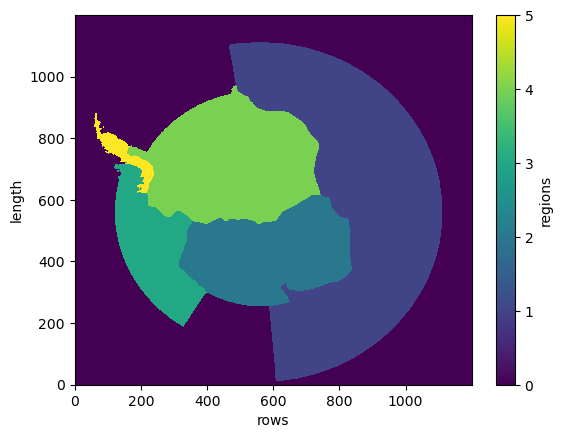

In [8]:
ds['regions'].plot.pcolormesh()

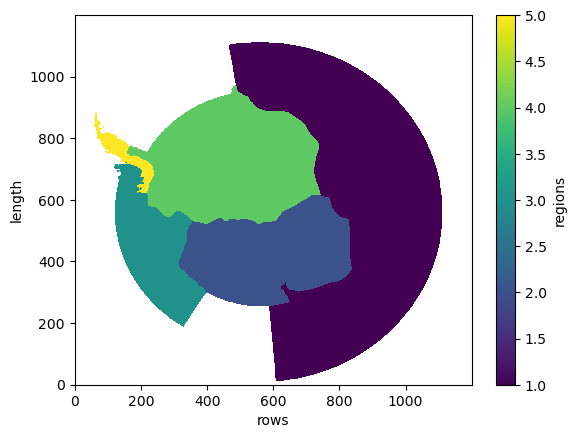

In [9]:
ds['regions'].where(ds['regions']!=0).plot.pcolormesh()

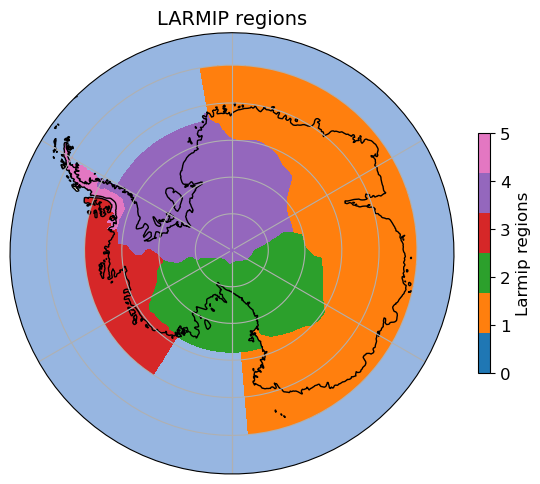

In [10]:
# Plot Antarctic map of LARMIP regions
sizemlf = 2 #size multiplication factor for higher res plots

cmin=0
cmax=5

f = plt.figure(figsize=(6,6))

ax = f.add_axes([0.1, 0.1,0.8, 0.8], projection=ccrs.SouthPolarStereo()) #left, bottom, width, height (range 0 to 1)

im = map_plotter(ds.regions.where(ds.regions), 
            ds.lon, ds.lat, ax, cmin, cmax, 
            'LARMIP regions')

cbar = f.colorbar(im, ax=ax, location='right', fraction =0.025)
cbar.set_label('Larmip regions', fontsize = 12)
cbar.ax.tick_params(labelsize=12)

plt.show()

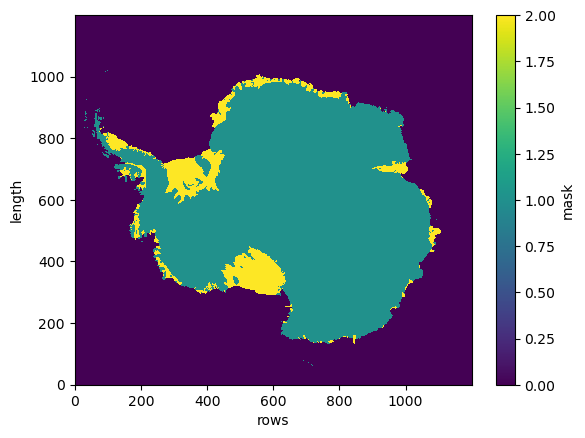

In [11]:
ds['mask'].plot.pcolormesh()

## Input grid

### Divide larmip regions into ocean and land part, to be regridded to NEMO and IFS grid respectively

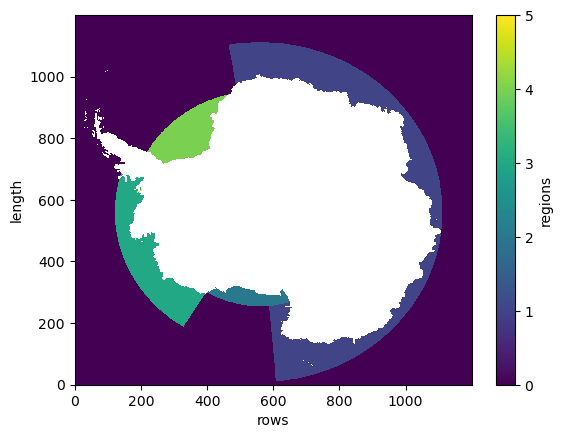

In [12]:
dr_ocean_regions = ds['regions'].where(ds['mask']==0)
dr_ocean_regions.plot.pcolormesh()

In [13]:
dr_ocean_regions

<xarray.DataArray 'regions' (length: 1200, rows: 1200)> Size: 12MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
    lon      (length, rows) float64 12MB -135.0 -135.1 -135.1 ... 44.96 45.0
    lat      (length, rows) float64 12MB -54.67 -54.7 -54.73 ... -50.08 -50.05
Dimensions without coordinates: length, rows

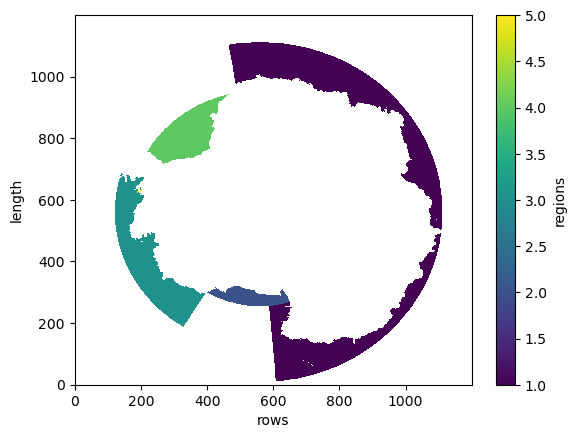

In [14]:
dr_ocean_regions.where(dr_ocean_regions).plot.pcolormesh()

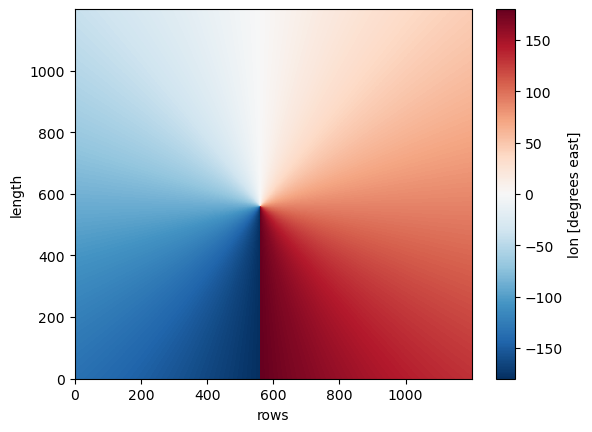

In [15]:
# Replace longitudes -180:180 to 0:360
dr_ocean_regions['lon'].plot.pcolormesh()


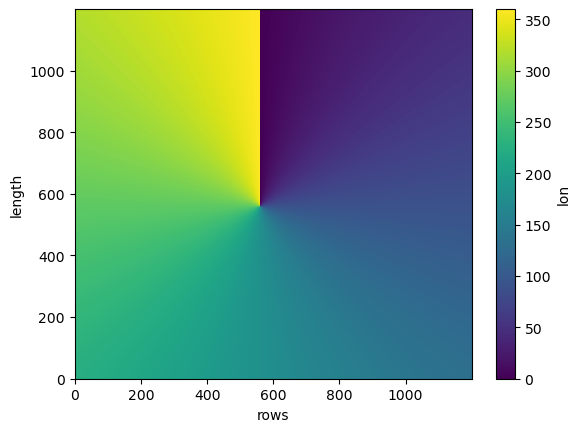

In [16]:
dr_ocean_regions['lon']=xr.where(dr_ocean_regions.lon<0, dr_ocean_regions.lon+360, dr_ocean_regions.lon )
dr_ocean_regions.lon.plot.pcolormesh()


In [17]:
mask_apen = dvp.mask_sector(dr_ocean_regions,'apen','lat','lon')
mask_apen


<xarray.DataArray (length: 1200, rows: 1200)> Size: 1MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
    lon      (length, rows) float64 12MB 225.0 224.9 224.9 ... 44.91 44.96 45.0
    lat      (length, rows) float64 12MB -54.67 -54.7 -54.73 ... -50.08 -50.05
Dimensions without coordinates: length, rows

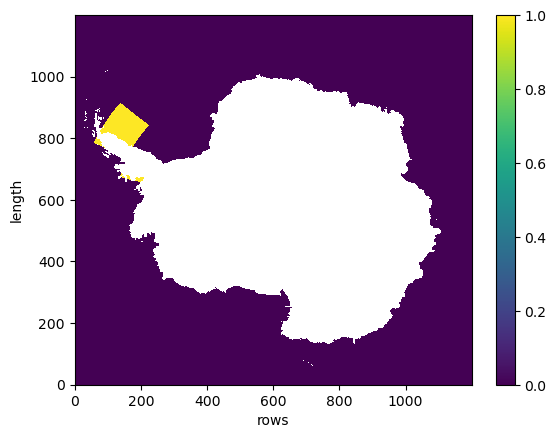

In [18]:
mask_apen = mask_apen.where(ds['mask']==0)
mask_apen.plot.pcolormesh()

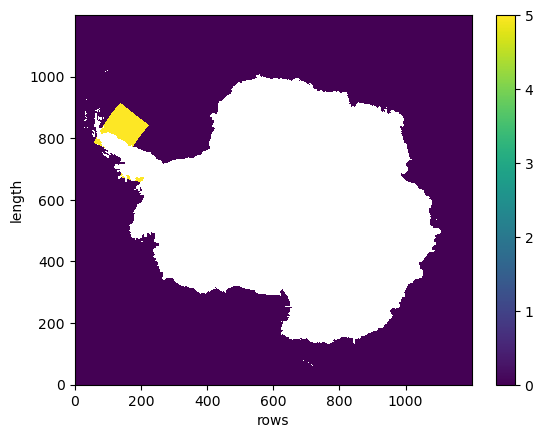

In [19]:
dr_five=xr.full_like(dr_ocean_regions,5)
dr_mask_apen=dr_five*mask_apen
dr_mask_apen.plot.pcolormesh()

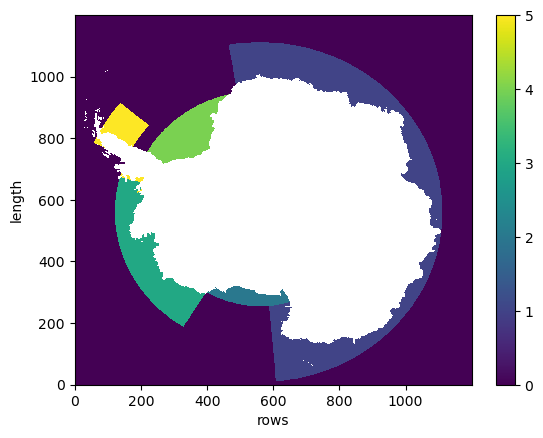

In [20]:
# Add Antarctic Peninsula to ocean regions
dr_ocean_5regions = dr_ocean_regions+dr_mask_apen
dr_ocean_5regions = dr_ocean_5regions.where(dr_ocean_5regions<8,5).where(ds['mask']==0) #Replace AMUN with APEN if regions overlap
dr_ocean_5regions.plot.pcolormesh()

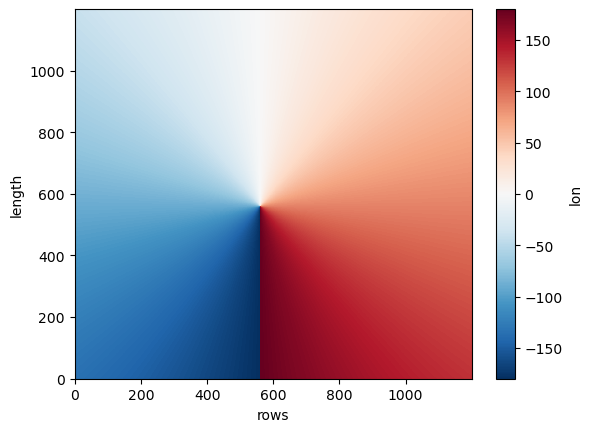

In [21]:
#Revert longitudes back to -180:180
dr_ocean_5regions['lon']=xr.where(dr_ocean_regions.lon>180, dr_ocean_regions.lon-360, dr_ocean_regions.lon )
dr_ocean_5regions.lon.plot.pcolormesh()

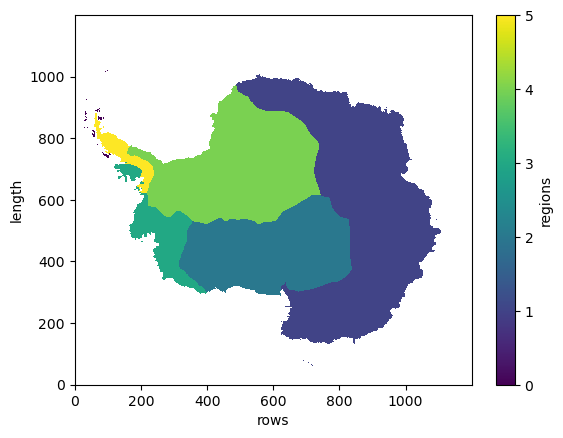

In [22]:
dr_land_regions = ds['regions'].where(ds['mask']!=0)
dr_land_regions.plot.pcolormesh()


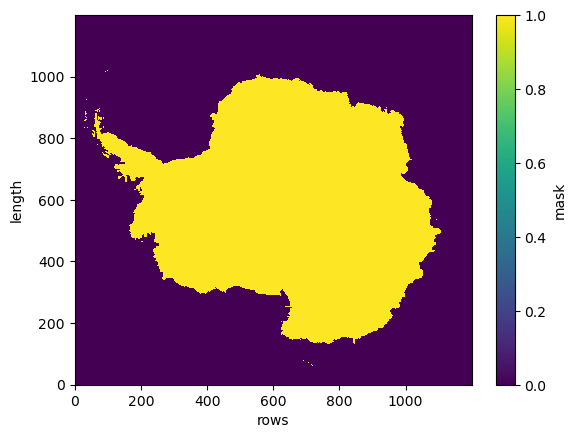

In [23]:
# Create mask with 0 over ocean and 1 over land (replace 2 with 1)
dr_land_mask=xr.where(ds['mask']>=1, 1,0)
dr_land_mask.plot.pcolormesh()

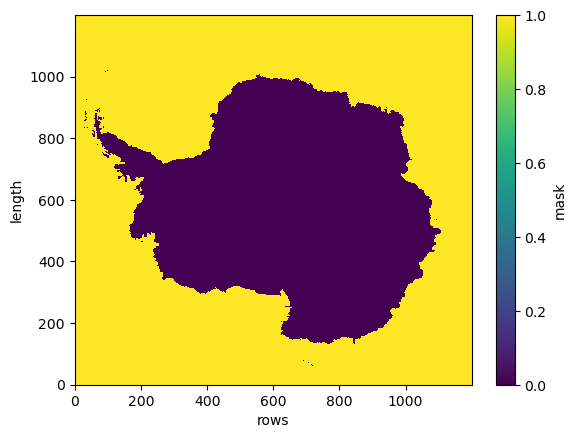

In [24]:
dr_ocean_mask=xr.where(ds['mask']==0,1,0)
dr_ocean_mask.plot.pcolormesh()

In [25]:
dr_ocean_mask

<xarray.DataArray 'mask' (length: 1200, rows: 1200)> Size: 12MB
array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])
Coordinates:
    lon      (length, rows) float64 12MB -135.0 -135.1 -135.1 ... 44.96 45.0
    lat      (length, rows) float64 12MB -54.67 -54.7 -54.73 ... -50.08 -50.05
Dimensions without coordinates: length, rows

In [26]:
ds

<xarray.Dataset> Size: 46MB
Dimensions:  (length: 1200, rows: 1200)
Coordinates:
    lon      (length, rows) float64 12MB -135.0 -135.1 -135.1 ... 44.96 45.0
    lat      (length, rows) float64 12MB -54.67 -54.7 -54.73 ... -50.08 -50.05
Dimensions without coordinates: length, rows
Data variables:
    mask     (length, rows) float64 12MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    regions  (length, rows) float64 12MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    history:  Mon Apr 22 14:07:45 2024: ncatted -O -a units,lat,c,c,degrees n...
    NCO:      netCDF Operators version 4.9.7 (Homepage = http://nco.sf.net, C...

In [27]:
ds_ocean=ds.drop_vars(['mask','regions'])
ds_ocean

<xarray.Dataset> Size: 23MB
Dimensions:  (length: 1200, rows: 1200)
Coordinates:
    lon      (length, rows) float64 12MB -135.0 -135.1 -135.1 ... 44.96 45.0
    lat      (length, rows) float64 12MB -54.67 -54.7 -54.73 ... -50.08 -50.05
Dimensions without coordinates: length, rows
Data variables:
    *empty*
Attributes:
    history:  Mon Apr 22 14:07:45 2024: ncatted -O -a units,lat,c,c,degrees n...
    NCO:      netCDF Operators version 4.9.7 (Homepage = http://nco.sf.net, C...

In [28]:
ds_ocean['regions']=dr_ocean_5regions
ds_ocean['mask']=dr_ocean_mask

In [29]:
ds_ocean

<xarray.Dataset> Size: 46MB
Dimensions:  (length: 1200, rows: 1200)
Coordinates:
    lon      (length, rows) float64 12MB -135.0 -135.1 -135.1 ... 44.96 45.0
    lat      (length, rows) float64 12MB -54.67 -54.7 -54.73 ... -50.08 -50.05
Dimensions without coordinates: length, rows
Data variables:
    regions  (length, rows) float64 12MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    mask     (length, rows) int64 12MB 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
Attributes:
    history:  Mon Apr 22 14:07:45 2024: ncatted -O -a units,lat,c,c,degrees n...
    NCO:      netCDF Operators version 4.9.7 (Homepage = http://nco.sf.net, C...

In [30]:
ds_land=ds.drop_vars(['mask','regions'])
ds_land['regions']=dr_land_regions
ds_land['mask']=dr_land_mask


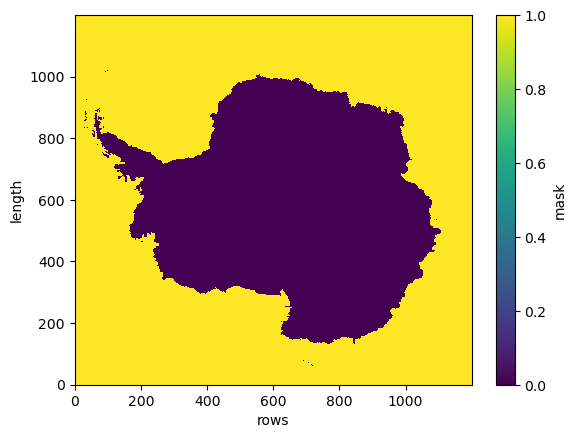

In [31]:
ds_ocean.mask.plot.pcolormesh()

## Output grid

### Ocean

In [32]:
file_nemo = f'/ec/res4/scratch/nk0j/ecearth3-cmip6/tes1/output/nemo/001/tes1_1y_18500101_18501231_opa_grid_T_2D.nc'
ds_nemo=xr.open_dataset(file_nemo)
ds_nemo

<xarray.Dataset> Size: 3MB
Dimensions:    (y: 292, x: 362)
Coordinates:
    nav_lat    (y, x) float32 423kB ...
    nav_lon    (y, x) float32 423kB ...
Dimensions without coordinates: y, x
Data variables:
    areacello  (y, x) float32 423kB ...
    basin      (y, x) float32 423kB ...
    hfgeou     (y, x) float32 423kB ...
    sftof      (y, x) float32 423kB ...
Attributes:
    name:         tes1_1y_18500101_18501231_opa_grid_T_2D
    description:  Created by xios
    title:        Created by xios
    Conventions:  CF-1.6
    timeStamp:    2024-Apr-10 14:12:12 GMT
    uuid:         7646c43d-b017-44d1-a799-c3bd7cd929bb

In [33]:
ds_nemo = ds_nemo.rename({'nav_lon':'lon','nav_lat':'lat'})
ds_nemo

<xarray.Dataset> Size: 3MB
Dimensions:    (y: 292, x: 362)
Coordinates:
    lat        (y, x) float32 423kB ...
    lon        (y, x) float32 423kB ...
Dimensions without coordinates: y, x
Data variables:
    areacello  (y, x) float32 423kB ...
    basin      (y, x) float32 423kB ...
    hfgeou     (y, x) float32 423kB ...
    sftof      (y, x) float32 423kB ...
Attributes:
    name:         tes1_1y_18500101_18501231_opa_grid_T_2D
    description:  Created by xios
    title:        Created by xios
    Conventions:  CF-1.6
    timeStamp:    2024-Apr-10 14:12:12 GMT
    uuid:         7646c43d-b017-44d1-a799-c3bd7cd929bb

<xarray.Dataset> Size: 3MB
Dimensions:    (y: 292, x: 362)
Coordinates:
    lat        (y, x) float32 423kB ...
    lon        (y, x) float32 423kB ...
Dimensions without coordinates: y, x
Data variables:
    areacello  (y, x) float32 423kB nan nan nan nan nan ... nan nan nan nan nan
    basin      (y, x) float32 423kB ...
    hfgeou     (y, x) float32 423kB ...
    sftof      (y, x) float32 423kB ...
    mask       (y, x) int64 846kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
Attributes:
    name:         tes1_1y_18500101_18501231_opa_grid_T_2D
    description:  Created by xios
    title:        Created by xios
    Conventions:  CF-1.6
    timeStamp:    2024-Apr-10 14:12:12 GMT
    uuid:         7646c43d-b017-44d1-a799-c3bd7cd929bb

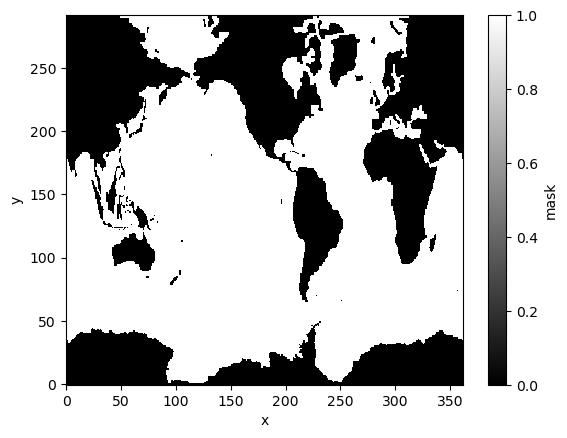

In [34]:
ds_nemo['mask'] = xr.where(~np.isnan(ds_nemo['areacello']),1,0)
ds_nemo['mask'].plot.pcolormesh(cmap='binary_r')
ds_nemo

In [35]:
dr_nemo_out = ds_nemo['mask']
#dr_nemo_out = dr_nemo_out.rename({'nav_lon':'lon','nav_lat':'lat'})
dr_nemo_out.name=''
dr_nemo_out

<xarray.DataArray '' (y: 292, x: 362)> Size: 846kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
    lat      (y, x) float32 423kB ...
    lon      (y, x) float32 423kB ...
Dimensions without coordinates: y, x

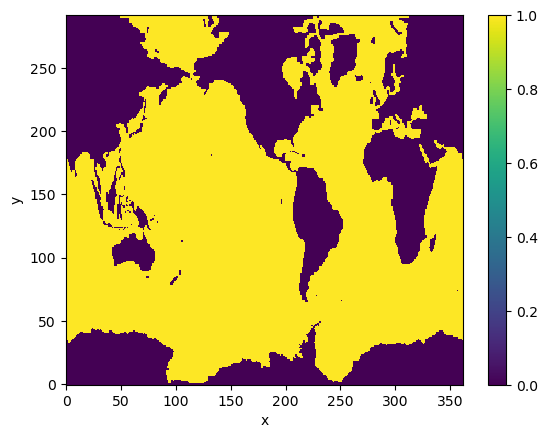

In [36]:
dr_nemo_out.plot.pcolormesh()

### Atmosphere

In [37]:
file_ifs = f'/ec/res4/hpcperm/nm6/ece3data/runoff-mapper/runoff_maps.nc'
ds_ifs=xr.open_dataset(file_ifs)
ds_ifs


<xarray.Dataset> Size: 2MB
Dimensions:            (lon: 512, lat: 256)
Coordinates:
  * lon                (lon) float64 4kB 0.0 0.7031 1.406 ... 357.9 358.6 359.3
  * lat                (lat) float64 2kB -89.46 -88.77 -88.07 ... 88.77 89.46
Data variables:
    drainage_basin_id  (lat, lon) int32 524kB ...
    arrival_point_id   (lat, lon) int32 524kB ...
    calving_point_id   (lat, lon) int32 524kB ...
Attributes:
    ece-origin:  Klaus Wyser (SMHI) for EC-Earth

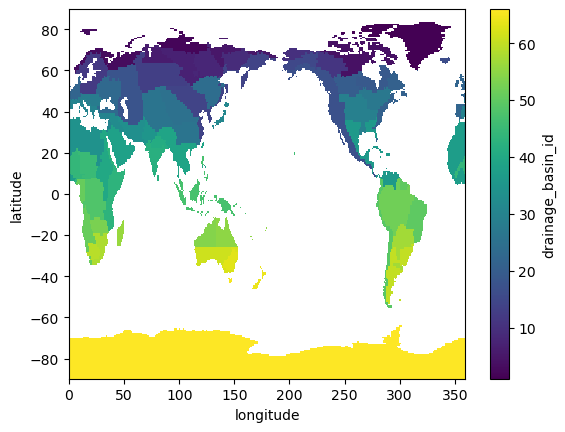

In [38]:
ds_ifs['drainage_basin_id'].where(ds_ifs['drainage_basin_id']>0).plot.pcolormesh()

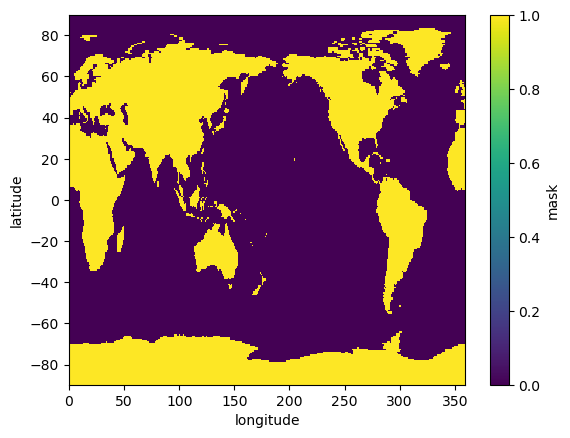

In [39]:
ds_ifs['mask'] = xr.where(ds_ifs['drainage_basin_id']>0,1,0)
ds_ifs['mask'].plot.pcolormesh()

In [40]:
ds_ifs

<xarray.Dataset> Size: 3MB
Dimensions:            (lon: 512, lat: 256)
Coordinates:
  * lon                (lon) float64 4kB 0.0 0.7031 1.406 ... 357.9 358.6 359.3
  * lat                (lat) float64 2kB -89.46 -88.77 -88.07 ... 88.77 89.46
Data variables:
    drainage_basin_id  (lat, lon) int32 524kB 66 66 66 66 66 ... -2 -2 -2 -2 -2
    arrival_point_id   (lat, lon) int32 524kB ...
    calving_point_id   (lat, lon) int32 524kB ...
    mask               (lat, lon) int64 1MB 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0
Attributes:
    ece-origin:  Klaus Wyser (SMHI) for EC-Earth

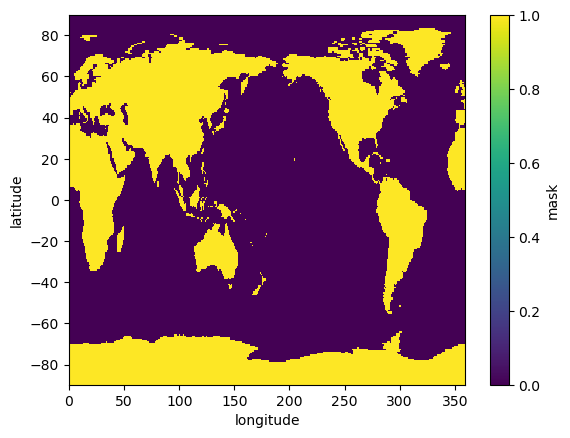

In [41]:
ds_ifs['mask'].plot.pcolormesh()

## Perform regridding

### Ocean

In [42]:
#Create regridder
#regridder_nemo = xe.Regridder(ds_ocean, ds_nemo, "nearest_s2d")
#regridder_nemo #print basic regridder information

In [43]:
#Write the weights to disk (to reload them later)
#fn = regridder_nemo.to_netcdf()
#print(fn)

In [44]:
#Retrieve regridder from netcdf weights
regridder_nemo2 = xe.Regridder(ds_ocean, ds_nemo, 'nearest_s2d', weights='nearest_s2d_1200x1200_292x362.nc')
regridder_nemo2

xESMF Regridder 
Regridding algorithm:       nearest_s2d 
Weight filename:            nearest_s2d_1200x1200_292x362.nc 
Reuse pre-computed weights? False 
Input grid shape:           (1200, 1200) 
Output grid shape:          (292, 362) 
Periodic in longitude?      False

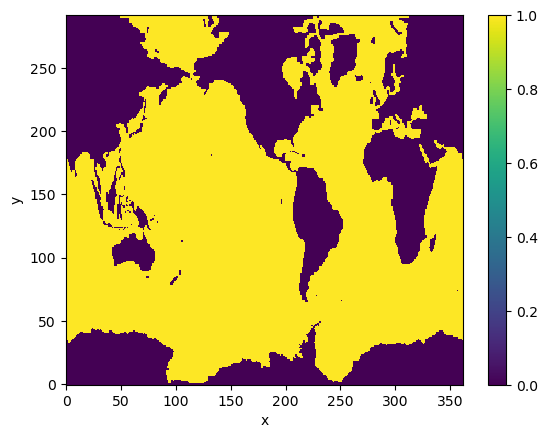

In [45]:
dr_nemo_out.plot.pcolormesh()

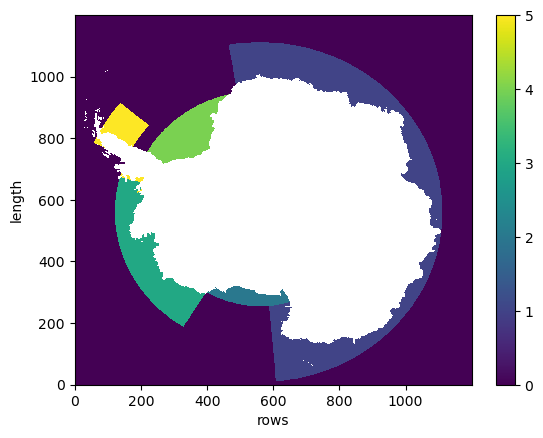

In [46]:
dr_ocean_5regions.plot.pcolormesh()

In [47]:
dr_ocean_regions_out = regridder_nemo2(dr_ocean_5regions)

In [48]:
dr_ocean_regions_out

<xarray.DataArray (y: 292, x: 362)> Size: 846kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    lat      (y, x) float32 423kB -78.39 -78.39 -78.39 ... 50.23 50.01 50.01
    lon      (y, x) float32 423kB 72.5 73.5 74.5 75.5 ... 73.05 73.04 73.0 72.99
Dimensions without coordinates: y, x
Attributes:
    regrid_method:  nearest_s2d

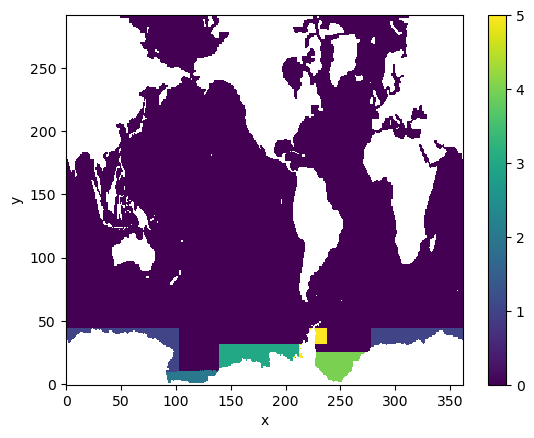

In [49]:
dr_ocean_regions_out.plot.pcolormesh()

In [50]:
dr_ocean_regions_out.name = 'regions'
ds_ocean_regions_out = dr_ocean_regions_out.to_dataset()
ds_ocean_regions_out

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 292, x: 362)
Coordinates:
    lat      (y, x) float32 423kB -78.39 -78.39 -78.39 ... 50.23 50.01 50.01
    lon      (y, x) float32 423kB 72.5 73.5 74.5 75.5 ... 73.05 73.04 73.0 72.99
Dimensions without coordinates: y, x
Data variables:
    regions  (y, x) float64 846kB nan nan nan nan nan ... nan nan nan nan nan

In [51]:
# Add NaNs over land (use dr_nemo_out in regridder)
#ds_ocean_regions_mask_out = ds_ocean_regions_out.where(dr_nemo_out==1)
#ds_ocean_regions_mask_out['regions'].plot.pcolormesh()

In [52]:
ds_ocean_regions_out.to_netcdf('/ec/res4/hpcperm/nk0j/ece3data_fwf/masks/LARMIP_ocean_regions_ORCA1.nc')

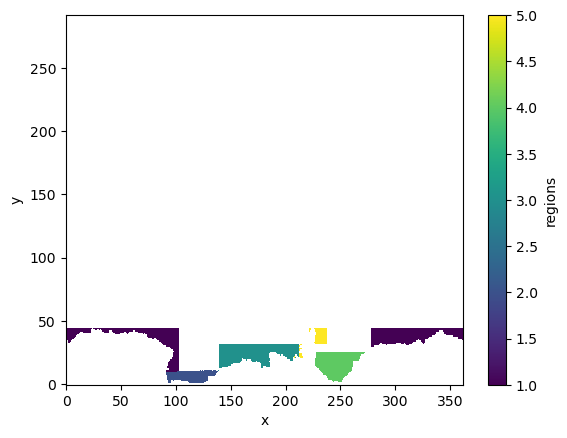

In [53]:
ds_ocean_regions_out = ds_ocean_regions_out.where(ds_ocean_regions_out>0)
ds_ocean_regions_out.regions.plot.pcolormesh()

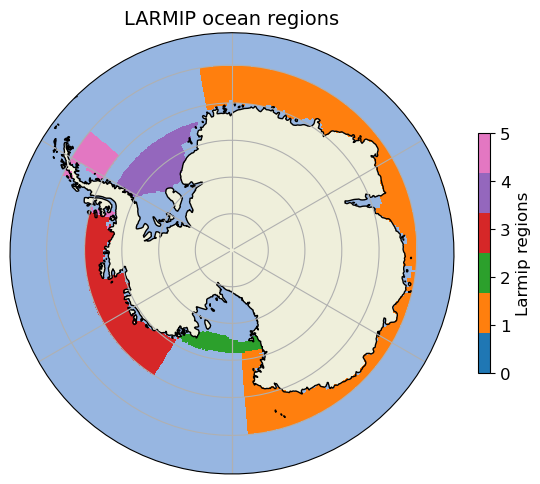

In [54]:
# Plot Antarctic map of LARMIP regions
sizemlf = 2 #size multiplication factor for higher res plots

cmin=0
cmax=5

f = plt.figure(figsize=(6,6))

ax = f.add_axes([0.1, 0.1,0.8, 0.8], projection=ccrs.SouthPolarStereo()) #left, bottom, width, height (range 0 to 1)

im = map_plotter(ds_ocean_regions_out['regions'].where(ds_ocean_regions_out['regions']), 
            ds_ocean_regions_out.lon, ds_ocean_regions_out.lat, ax, cmin, cmax, 
            'LARMIP ocean regions')

cbar = f.colorbar(im, ax=ax, location='right', fraction =0.025)
cbar.set_label('Larmip regions', fontsize = 12)
cbar.ax.tick_params(labelsize=12)

plt.show()

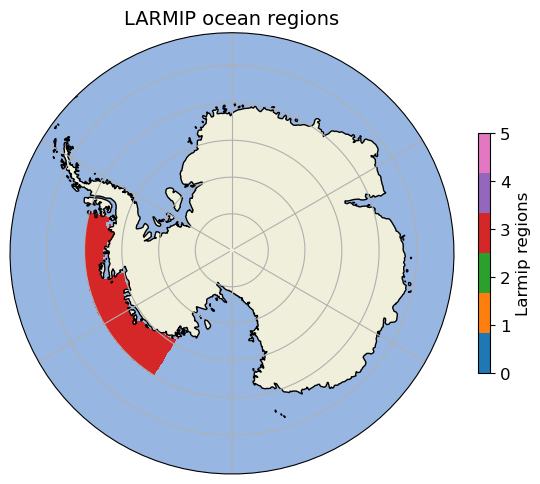

In [55]:
# Plot Antarctic map of LARMIP regions
sizemlf = 2 #size multiplication factor for higher res plots

cmin=0
cmax=5

f = plt.figure(figsize=(6,6))

ax = f.add_axes([0.1, 0.1,0.8, 0.8], projection=ccrs.SouthPolarStereo()) #left, bottom, width, height (range 0 to 1)

im = map_plotter(ds_ocean_regions_out.regions.where(ds_ocean_regions_out.regions==3), 
            ds_ocean_regions_out.lon, ds_ocean_regions_out.lat, ax, cmin, cmax, 
            'LARMIP ocean regions')

cbar = f.colorbar(im, ax=ax, location='right', fraction =0.025)
cbar.set_label('Larmip regions', fontsize = 12)
cbar.ax.tick_params(labelsize=12)

plt.show()

### Atmosphere

In [56]:
#regridder_ifs = xe.Regridder(ds_land, ds_ifs, "nearest_s2d")
#regridder_ifs #print basic regridder information

In [57]:
#Write the weights to disk (to reload them later)
#fn = regridder_ifs.to_netcdf()
#print(fn)

In [58]:
#Retrieve regridder from netcdf weights
regridder_ifs2 = xe.Regridder(ds_land, ds_ifs, 'nearest_s2d', weights='nearest_s2d_1200x1200_256x512.nc')

In [59]:
dr_land_regions_out = regridder_ifs2(dr_land_regions)

In [60]:
dr_land_regions_out

<xarray.DataArray (lat: 256, lon: 512)> Size: 1MB
array([[ 4.,  4.,  4., ...,  4.,  4.,  4.],
       [ 4.,  4.,  4., ...,  4.,  4.,  4.],
       [ 4.,  4.,  4., ...,  4.,  4.,  4.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
  * lat      (lat) float64 2kB -89.46 -88.77 -88.07 -87.37 ... 88.07 88.77 89.46
Attributes:
    regrid_method:  nearest_s2d

In [61]:
dr_land_regions_out.name = 'regions'
ds_land_regions_out = dr_land_regions_out.to_dataset()
ds_land_regions_out

<xarray.Dataset> Size: 1MB
Dimensions:  (lon: 512, lat: 256)
Coordinates:
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
  * lat      (lat) float64 2kB -89.46 -88.77 -88.07 -87.37 ... 88.07 88.77 89.46
Data variables:
    regions  (lat, lon) float64 1MB 4.0 4.0 4.0 4.0 4.0 ... nan nan nan nan nan

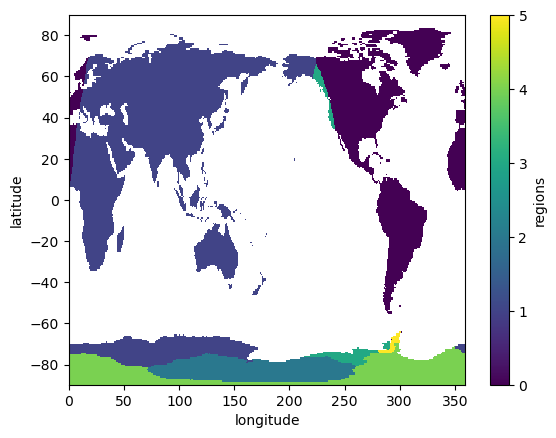

In [62]:
ds_land_regions_out.regions.plot.pcolormesh()

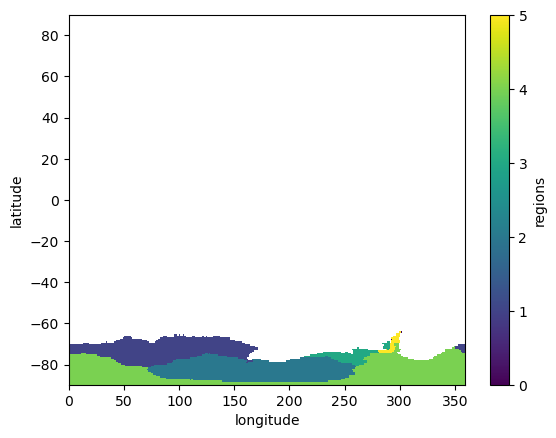

In [63]:
# Remove continents other than Antarctica
ds_land_regions_out = ds_land_regions_out.where(ds_land_regions_out['lat']<=-56)
ds_land_regions_out['regions'].plot.pcolormesh()

In [64]:
ds_land_regions_out

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 256, lon: 512)
Coordinates:
  * lon      (lon) float64 4kB 0.0 0.7031 1.406 2.109 ... 357.9 358.6 359.3
  * lat      (lat) float64 2kB -89.46 -88.77 -88.07 -87.37 ... 88.07 88.77 89.46
Data variables:
    regions  (lat, lon) float64 1MB 4.0 4.0 4.0 4.0 4.0 ... nan nan nan nan nan

In [65]:
ds_land_regions_out.to_netcdf('/ec/res4/hpcperm/nk0j/ece3data_fwf/masks/LARMIP_landice_regions_T255.nc')

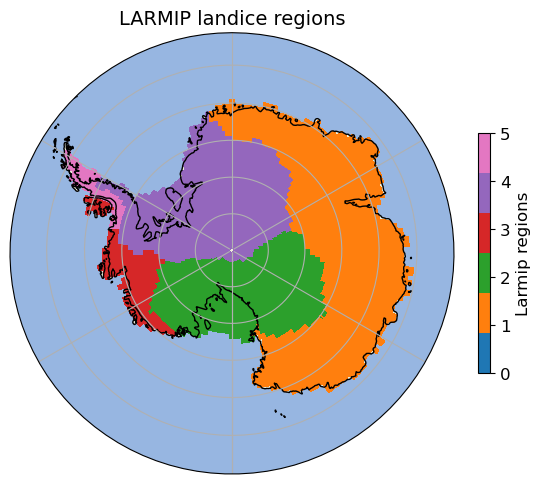

In [68]:
# Plot Antarctic map of LARMIP regions
sizemlf = 2 #size multiplication factor for higher res plots

cmin=0
cmax=5

f = plt.figure(figsize=(6,6))

ax = f.add_axes([0.1, 0.1,0.8, 0.8], projection=ccrs.SouthPolarStereo()) #left, bottom, width, height (range 0 to 1)

im = map_plotter(ds_land_regions_out['regions'].where(ds_land_regions_out['regions']), 
            ds_land_regions_out.lon, ds_land_regions_out.lat, ax, cmin, cmax, 
            'LARMIP landice regions')

cbar = f.colorbar(im, ax=ax, location='right', fraction =0.025)
cbar.set_label('Larmip regions', fontsize = 12)
cbar.ax.tick_params(labelsize=12)

plt.show()

## Divide calving and basal melt masks into five regions 

In [ ]:
fn_basal_melt_mask = 
fn_calving_mask = 